# Chapter 2 Practical 06: Graph-Based Content Recommendation

Learning objectives:
- Build a movie graph from shared content features.
- Visualize movies as nodes and content relationships as edges.
- Compute graph-based similarity using shared neighbors.
- Understand the message-passing idea in simple terms.

Slide connection: graph-based content recommendation, item relationships, graph neighborhoods, and optional graph embeddings.


A content graph connects items when they share features such as genres, directors, or high text similarity.


In [1]:
# Teaching note: Load movies with a Colab-safe fallback. Local files are used first; GitHub raw CSV is used when the notebook is opened directly from GitHub.
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIRS = [
    Path("data"),
    Path("../data"),
    Path("chapter_02_content_based/data"),
]
GITHUB_DATA_URL = "https://raw.githubusercontent.com/MehrdadJalali-AI/RecommenderSystems/main/chapter_02_content_based/data"

def read_chapter2_csv(filename):
    for data_dir in DATA_DIRS:
        csv_path = data_dir / filename
        if csv_path.exists():
            print(f"Loaded {filename} from {csv_path}")
            return pd.read_csv(csv_path)
    url = f"{GITHUB_DATA_URL}/{filename}"
    print(f"Local file not found. Loading {filename} from GitHub raw URL.")
    return pd.read_csv(url)

movies = read_chapter2_csv("movies_chapter2.csv")
movies.head()


Loaded movies_chapter2.csv from data/movies_chapter2.csv


,movie_id,title,genres,director,year,duration_min,rating,family_friendly,description,keywords
0,1,Inception,Sci-Fi|Thriller|Action,Christopher Nolan,2010,148,8.8,0,A thief enters layered dreams to plant an idea...,dreams heist subconscious mind-bending
1,2,Interstellar,Sci-Fi|Adventure|Drama,Christopher Nolan,2014,169,8.7,0,Astronauts travel through a wormhole to find a...,space exploration wormhole survival family
2,3,Titanic,Romance|Drama,James Cameron,1997,195,7.9,0,A young couple from different social classes f...,romance ship tragedy historical
3,4,The Matrix,Sci-Fi|Action,The Wachowskis,1999,136,8.7,0,A hacker discovers that reality is a simulated...,simulation hacker reality action cyberpunk
4,5,Toy Story,Animation|Adventure|Comedy|Family,John Lasseter,1995,81,8.3,1,A cowboy doll feels threatened when a space ra...,toys friendship family adventure


Build a graph where nodes are movies and edges mean shared genre or same director.


In [2]:
# Teaching note: Build a content graph connecting movies to genres, directors, and keywords.
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations

# A graph stores users/items as nodes and interactions as edges.
G = nx.Graph()
for _, row in movies.iterrows():
    G.add_node(row["title"], genres=set(row["genres"].split("|")), director=row["director"], rating=row["rating"])

for a, b in combinations(movies["title"], 2):
    a_data, b_data = G.nodes[a], G.nodes[b]
    shared_genres = a_data["genres"] & b_data["genres"]
    same_director = a_data["director"] == b_data["director"]
    if shared_genres or same_director:
        weight = len(shared_genres) + (1.5 if same_director else 0)
        reason = ", ".join(sorted(shared_genres))
        if same_director:
            reason = (reason + ", " if reason else "") + "same director"
        G.add_edge(a, b, weight=weight, reason=reason)

print("nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())
list(G.edges(data=True))[:8]


nodes: 12 edges: 35


[('Inception',
  'Interstellar',
  {'weight': 2.5, 'reason': 'Sci-Fi, same director'}),
 ('Inception', 'The Matrix', {'weight': 2, 'reason': 'Action, Sci-Fi'}),
 ('Inception',
  'The Dark Knight',
  {'weight': 2.5, 'reason': 'Action, same director'}),
 ('Inception', 'The Martian', {'weight': 1, 'reason': 'Sci-Fi'}),
 ('Inception', 'Gravity', {'weight': 2, 'reason': 'Sci-Fi, Thriller'}),
 ('Interstellar', 'Titanic', {'weight': 1, 'reason': 'Drama'}),
 ('Interstellar', 'The Matrix', {'weight': 1, 'reason': 'Sci-Fi'}),
 ('Interstellar', 'Toy Story', {'weight': 1, 'reason': 'Adventure'})]

Visualize the graph. Thicker edges mean stronger content overlap.


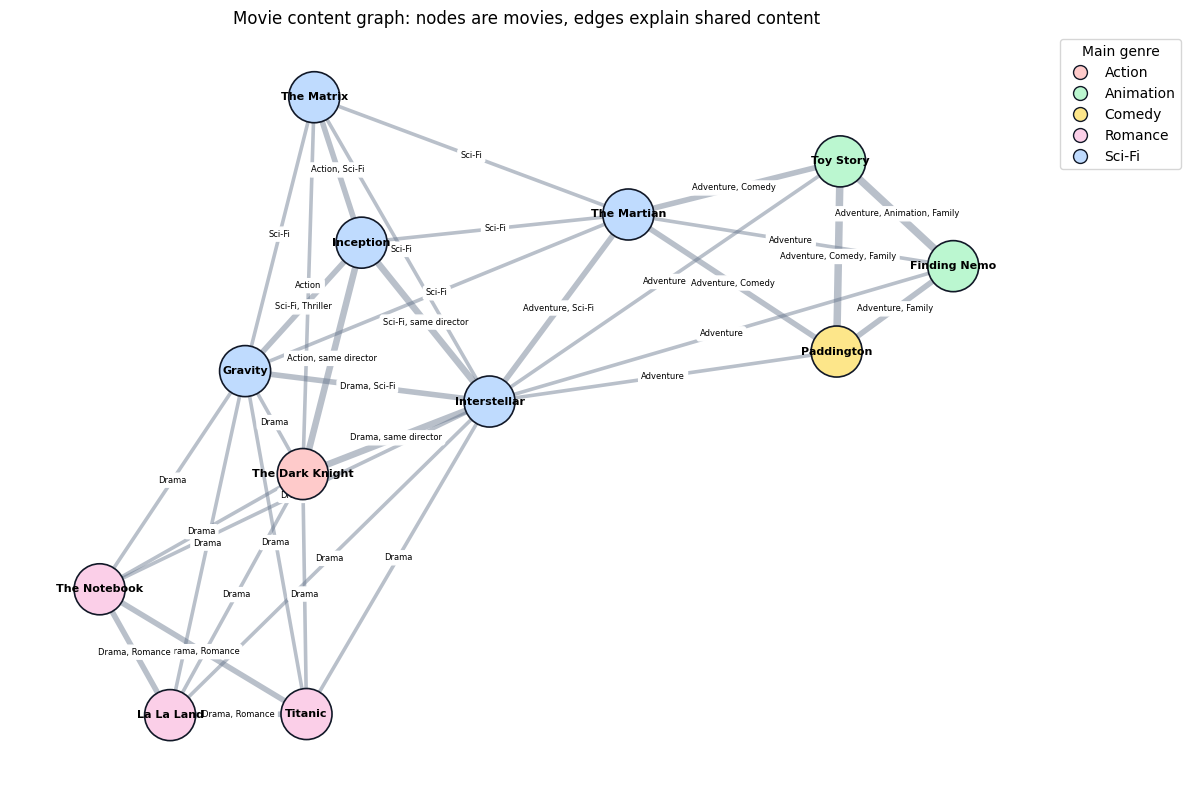

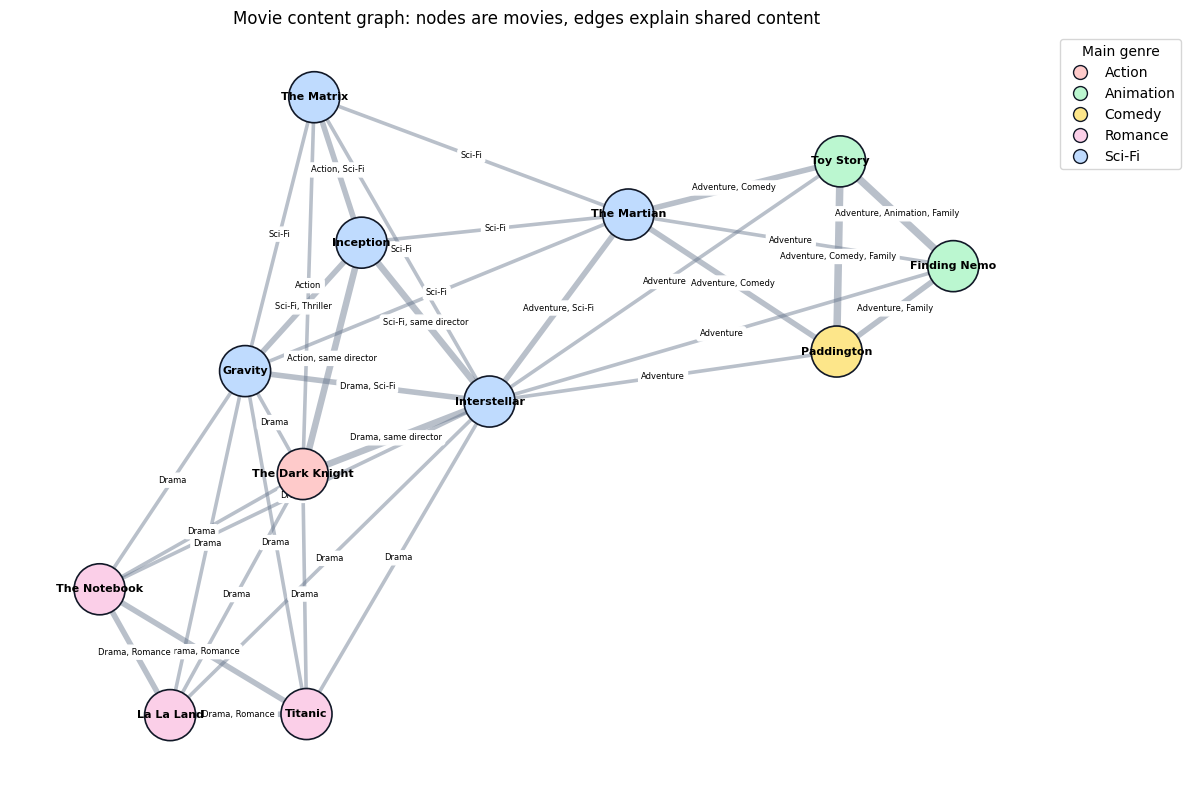

In [3]:
# Teaching note: Draw the graph with node colors, edge thickness, and edge labels so the structure is easier to read.
main_genre = {row["title"]: row["genres"].split("|")[0] for _, row in movies.iterrows()}
genre_palette = {
    "Action": "#fecaca",
    "Animation": "#bbf7d0",
    "Comedy": "#fde68a",
    "Romance": "#fbcfe8",
    "Sci-Fi": "#bfdbfe",
}
node_colors = [genre_palette.get(main_genre[node], "#e5e7eb") for node in G.nodes]
pos = nx.spring_layout(G, seed=11, k=0.85)
edge_widths = [1.2 + 1.4 * G[u][v]["weight"] for u, v in G.edges()]

fig, ax = plt.subplots(figsize=(12, 8))
nx.draw_networkx_edges(G, pos, width=edge_widths, alpha=0.45, edge_color="#64748b", ax=ax)
nx.draw_networkx_nodes(G, pos, node_size=1350, node_color=node_colors, edgecolors="#111827", linewidths=1.2, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold", ax=ax)

# Edge labels show why two movies are connected, which turns the graph into an explanation tool.
edge_labels = {(u, v): G[u][v]["reason"] for u, v in G.edges()}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=6, rotate=False, ax=ax)

legend_handles = [
    plt.Line2D([0], [0], marker="o", color="w", label=genre, markerfacecolor=color, markeredgecolor="#111827", markersize=10)
    for genre, color in genre_palette.items()
]
ax.legend(handles=legend_handles, title="Main genre", loc="upper left", bbox_to_anchor=(1.01, 1))
ax.set_title("Movie content graph: nodes are movies, edges explain shared content")
ax.axis("off")
plt.tight_layout()
fig


A simple graph similarity score can combine direct edge strength and shared neighbors.


,input_movie,recommended_movie,graph_score,direct_edge_weight,shared_neighbors,edge_reason
5,Interstellar,The Dark Knight,5.5,2.5,"Inception, Titanic, The Matrix, The Notebook, ...","Drama, same director"
9,Interstellar,Gravity,5.5,2.0,"Inception, Titanic, The Matrix, The Dark Knigh...","Drama, Sci-Fi"
6,Interstellar,The Martian,5.0,2.0,"Inception, The Matrix, Toy Story, Finding Nemo...","Adventure, Sci-Fi"
0,Interstellar,Inception,4.5,2.5,"The Matrix, The Dark Knight, The Martian, Gravity","Sci-Fi, same director"
1,Interstellar,Titanic,3.0,1.0,"The Dark Knight, The Notebook, Gravity, La La ...",Drama
2,Interstellar,The Matrix,3.0,1.0,"Inception, The Dark Knight, The Martian, Gravity",Sci-Fi


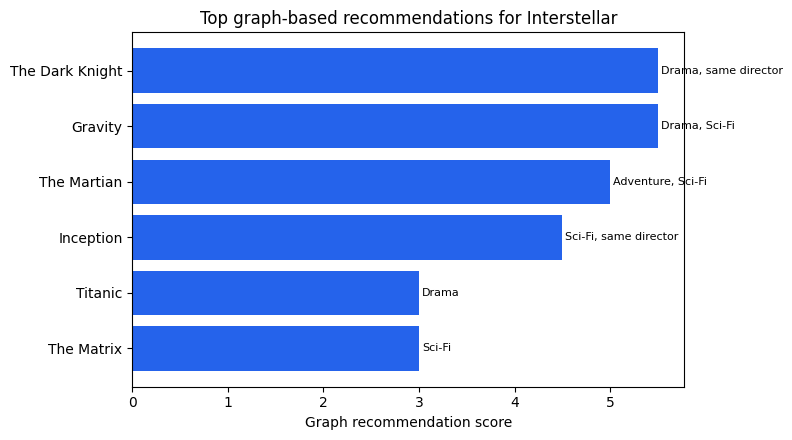

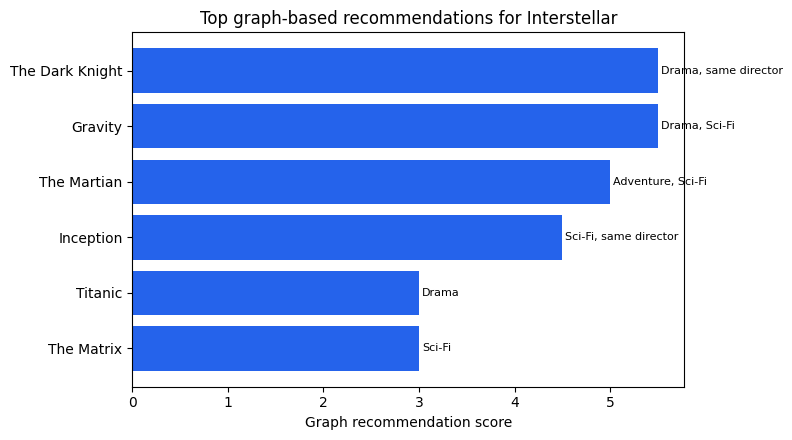

In [4]:
# Teaching note: Rank graph recommendations and visualize how direct edges plus shared neighbors form the score.
def graph_similarity(source, target):
    direct = G[source][target]["weight"] if G.has_edge(source, target) else 0
    common_neighbors = list(nx.common_neighbors(G, source, target))
    two_hop_bonus = 0.5 * len(common_neighbors)
    return direct + two_hop_bonus, direct, common_neighbors

def graph_recommend(title, n=5):
    rows = []
    for other in G.nodes:
        if other == title:
            continue
        score, direct, common_neighbors = graph_similarity(title, other)
        rows.append({
            "input_movie": title,
            "recommended_movie": other,
            "graph_score": score,
            "direct_edge_weight": direct,
            "shared_neighbors": ", ".join(common_neighbors) if common_neighbors else "none",
            "edge_reason": G[title][other]["reason"] if G.has_edge(title, other) else "two-hop graph evidence",
        })
    return pd.DataFrame(rows).sort_values("graph_score", ascending=False).head(n)

recommendations = graph_recommend("Interstellar", n=6)
display(recommendations)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(recommendations["recommended_movie"], recommendations["graph_score"], color="#2563eb")
ax.invert_yaxis()
ax.set_xlabel("Graph recommendation score")
ax.set_title("Top graph-based recommendations for Interstellar")
for i, row in recommendations.reset_index(drop=True).iterrows():
    ax.text(row["graph_score"] + 0.03, i, row["edge_reason"], va="center", fontsize=8)
plt.tight_layout()
fig


Centrality can identify well-connected items. This is not personalization by itself, but it helps explain graph structure.


,degree_centrality
Interstellar,1.000
Gravity,0.727
The Dark Knight,0.636
The Martian,0.636
Inception,0.455
Titanic,0.455
The Matrix,0.455
The Notebook,0.455


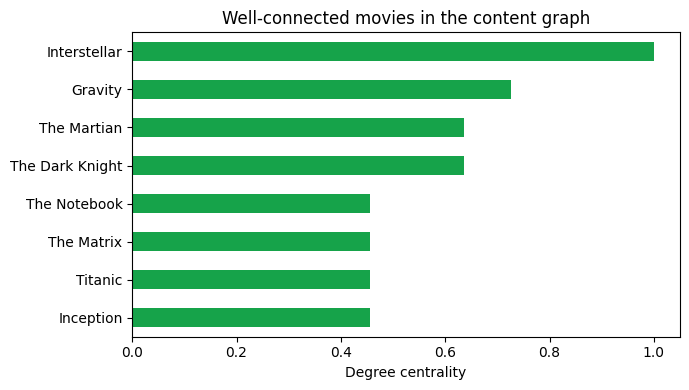

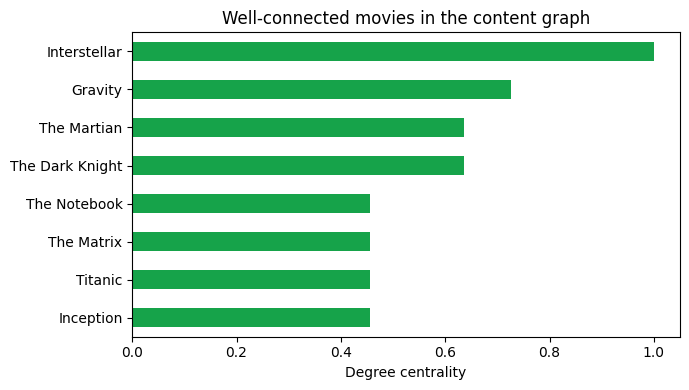

In [5]:
# Teaching note: Centrality highlights movies that connect many parts of the graph.
centrality = pd.Series(nx.degree_centrality(G), name="degree_centrality").sort_values(ascending=False)
centrality_table = centrality.head(8).round(3).to_frame()
display(centrality_table)

fig, ax = plt.subplots(figsize=(7, 4))
centrality_table.sort_values("degree_centrality").plot(kind="barh", legend=False, ax=ax, color="#16a34a")
ax.set_xlabel("Degree centrality")
ax.set_title("Well-connected movies in the content graph")
plt.tight_layout()
fig


Optional node embeddings can be useful, but the notebook remains runnable without them.


In [6]:
# Teaching note: Visualize the graph so students can see how content relationships connect items.
try:
    from node2vec import Node2Vec
    node2vec = Node2Vec(G, dimensions=8, walk_length=5, num_walks=30, workers=1, quiet=True, seed=7)
    model = node2vec.fit(window=3, min_count=1, batch_words=16)
    print("Node2Vec embeddings learned.")
    print(model.wv.most_similar("Interstellar", topn=5))
except Exception as exc:
    print("Optional Node2Vec is not available. The NetworkX graph recommendation above is the fallback.")
    print(type(exc).__name__, str(exc)[:160])


Optional Node2Vec is not available. The NetworkX graph recommendation above is the fallback.
ModuleNotFoundError No module named 'node2vec'


Message passing idea:

Each movie can receive information from its neighbors. After one step, a movie knows about directly connected movies. After two steps, it also receives signals from neighbors of neighbors. Graph neural networks formalize this idea with learned transformations.

## What did we learn?

- Graphs represent relationships between items, not only feature rows.
- Shared genres and directors can create interpretable edges.
- Edge labels, node colors, and score bars make graph recommendations easier to understand.
- A simple NetworkX fallback is enough to teach graph-based recommendation before advanced GNNs.

## Challenge Lab

1. Change the same-director bonus in the edge weight formula from `1.5` to `0.5`, rebuild the graph, and identify which recommendations for `Interstellar` change.
2. Create a two-movie seed profile, such as `Interstellar` plus `Gravity`, by averaging their graph recommendation scores. Which movie becomes the top recommendation, and what graph evidence explains it?
